# Data Preparation

In [ ]:
# persiapkan library yang dibutuhkan
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

In [ ]:
# Load dataset
df = pd.read_csv('/content/sample_data/cardio_train.csv', sep=';')

# 5 baris pertama untuk melihat struktur data
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Data Understanding

In [ ]:
# Ukuran dataset
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')

Jumlah baris  : 70,000
Jumlah kolom  : 13


In [ ]:
# Tipe data dan missing value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
# Cek missing value
print('Jumlah missing value per kolom:')
print(df.isnull().sum())

Jumlah missing value per kolom:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [ ]:
# Statistik deskriptif
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Distribusi kelas target (cardio):
cardio
0    35021
1    34979
Name: count, dtype: int64

Proporsi:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64%


/tmp/ipykernel_1749/2102091485.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='Set2')


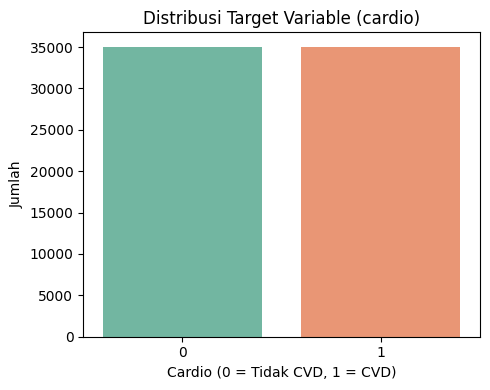

In [ ]:
# Distribusi target variable (cardio)
print('Distribusi kelas target (cardio):')
print(df['cardio'].value_counts())
print(f"\nProporsi:\n{df['cardio'].value_counts(normalize=True).round(4) * 100}%")

# Visualisasi distribusi target
plt.figure(figsize=(5, 4))
sns.countplot(x='cardio', data=df, palette='Set2')
plt.title('Distribusi Target Variable (cardio)')
plt.xlabel('Cardio (0 = Tidak CVD, 1 = CVD)')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

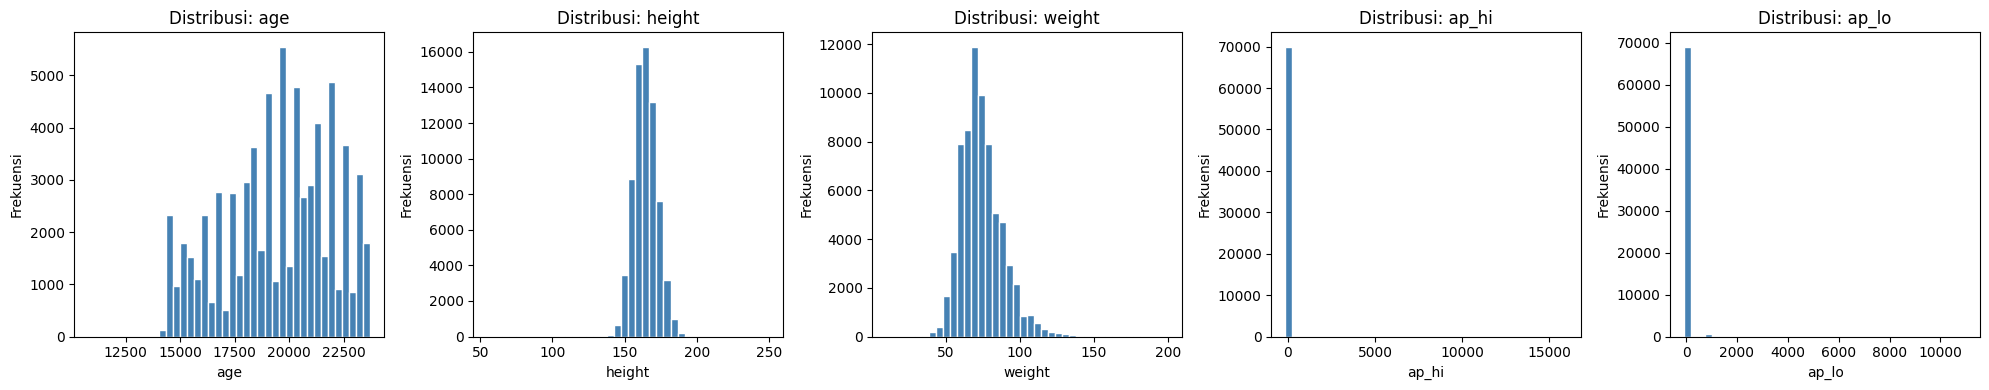

In [ ]:
# Distribusi fitur numerik
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [ ]:
# Deteksi outlier pada fitur tekanan darah (ap_hi dan ap_lo)
# Secara medis, tekanan darah sistolik (ap_hi) yang valid: 60-250 mmHg
# Tekanan darah diastolik (ap_lo) yang valid: 40-200 mmHg
print('Nilai min & max ap_hi (sistolik):', df['ap_hi'].min(), '-', df['ap_hi'].max())
print('Nilai min & max ap_lo (diastolik):', df['ap_lo'].min(), '-', df['ap_lo'].max())
print('\nJumlah nilai ap_hi tidak wajar (< 60 atau > 250):', ((df['ap_hi'] < 60) | (df['ap_hi'] > 250)).sum())
print('Jumlah nilai ap_lo tidak wajar (< 40 atau > 200):', ((df['ap_lo'] < 40) | (df['ap_lo'] > 200)).sum())

Nilai min & max ap_hi (sistolik): -150 - 16020
Nilai min & max ap_lo (diastolik): -70 - 11000

Jumlah nilai ap_hi tidak wajar (< 60 atau > 250): 228
Jumlah nilai ap_lo tidak wajar (< 40 atau > 200): 1012


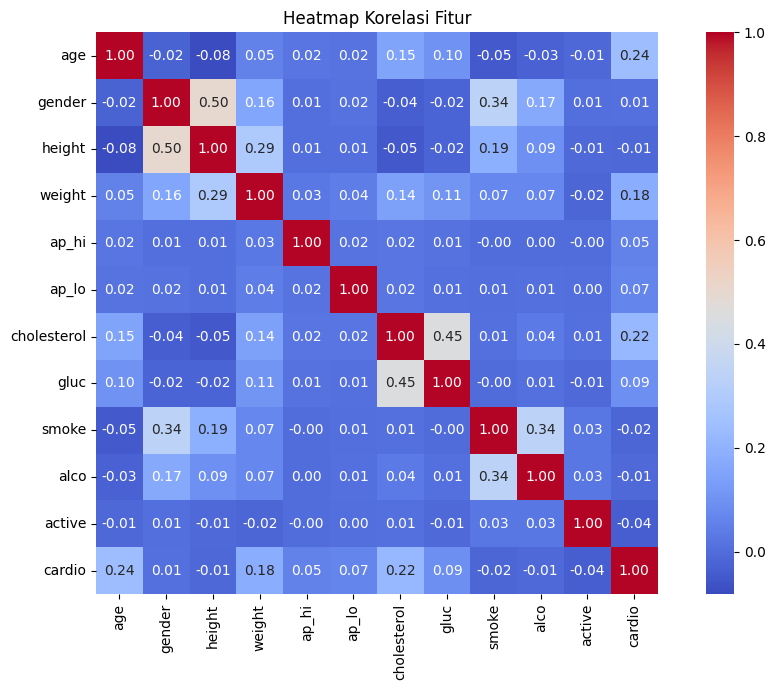

In [ ]:
# Heatmap korelasi antar fitur numerik
plt.figure(figsize=(10, 7))
corr = df.drop(columns=['id']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

Dataset memiliki 70.000 baris dan 13 kolom (11 fitur + 1 ID + 1 target). Tidak ditemukan missing value. Target variable `cardio` terdistribusi seimbang (~50% tiap kelas) sehingga tidak ada masalah class imbalance. Ditemukan nilai outlier pada fitur `ap_hi` dan `ap_lo` yang perlu dibersihkan pada tahap preprocessing.

## Data Preprocessing

In [ ]:
# Langkah 1: Drop kolom 'id' karena bukan fitur prediktif
df = df.drop(columns=['id'])
print('Kolom setelah drop id:', list(df.columns))

Kolom setelah drop id: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [ ]:
# Langkah 2: Konversi usia dari hari ke tahun
df['age'] = (df['age'] / 365).round(0).astype(int)
print('Rentang usia setelah konversi (tahun):', df['age'].min(), '-', df['age'].max())

Rentang usia setelah konversi (tahun): 30 - 65


In [ ]:
# Langkah 3: Hapus outlier pada tekanan darah (ap_hi dan ap_lo)
# Filter berdasarkan batas medis yang wajar
df = df[
    (df['ap_hi'] >= 60) & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40) & (df['ap_lo'] <= 200) &
    (df['ap_hi'] > df['ap_lo'])  # sistolik harus lebih besar dari diastolik
]

print(f'Jumlah data setelah remove outlier: {df.shape[0]:,}')

Jumlah data setelah remove outlier: 68,672


In [ ]:
# Langkah 4: Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['cardio'])
y = df['cardio']

print('Shape X (fitur):', X.shape)
print('Shape y (target):', y.shape)

Shape X (fitur): (68672, 11)
Shape y (target): (68672,)


In [ ]:
# Langkah 5: Split data train dan test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ukuran data train : {X_train.shape[0]:,}')
print(f'Ukuran data test  : {X_test.shape[0]:,}')

Ukuran data train : 54,937
Ukuran data test  : 13,735


In [ ]:
# Langkah 6: Normalisasi fitur numerik menggunakan StandardScaler
# Scaling dilakukan SETELAH split untuk menghindari data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Preprocessing selesai. Data siap untuk modeling.')

Preprocessing selesai. Data siap untuk modeling.


Ringkasan tahap preprocessing:
- Kolom `id` di-drop karena tidak relevan sebagai fitur prediktif
- Fitur `age` dikonversi dari satuan hari ke tahun
- Outlier pada `ap_hi` dan `ap_lo` dihapus berdasarkan batas medis yang wajar
- Data di-split 80% training dan 20% testing dengan stratifikasi untuk menjaga proporsi kelas
- Scaling dilakukan setelah split → **tidak ada data leakage**
- Data siap untuk tahap modeling

## Modeling & Evaluasi

### Logistic Regression (Baseline)

In [ ]:
# Model 1: Logistic Regression sebagai model baseline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

# Evaluasi
print('=== Evaluasi Logistic Regression (Baseline) ===')
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_lr)}")

=== Evaluasi Logistic Regression (Baseline) ===
Accuracy  : 0.7228
Precision : 0.7516
Recall    : 0.6567
F1-Score  : 0.7009

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6940
           1       0.75      0.66      0.70      6795

    accuracy                           0.72     13735
   macro avg       0.73      0.72      0.72     13735
weighted avg       0.73      0.72      0.72     13735



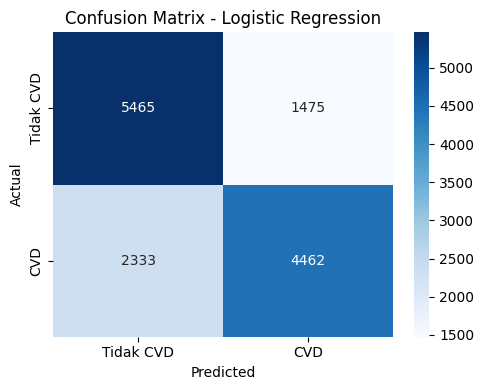

In [ ]:
# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak CVD', 'CVD'],
            yticklabels=['Tidak CVD', 'CVD'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# Cek overfitting Logistic Regression
y_train_pred_lr = lr.predict(X_train_scaled)

print('=== Overfitting Check - Logistic Regression ===')
print('Train Accuracy :', round(accuracy_score(y_train, y_train_pred_lr), 4))
print('Test Accuracy  :', round(accuracy_score(y_test, y_pred_lr), 4))

=== Overfitting Check - Logistic Regression ===
Train Accuracy : 0.7285
Test Accuracy  : 0.7228


### Random Forest (Model Pembanding)

In [ ]:
# Model 2: Random Forest sebagai model pembanding
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

# Evaluasi
print('=== Evaluasi Random Forest (Model Pembanding) ===')
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rf)}")

=== Evaluasi Random Forest (Model Pembanding) ===
Accuracy  : 0.6984
Precision : 0.6988
Recall    : 0.6862
F1-Score  : 0.6925

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.71      0.70      6940
           1       0.70      0.69      0.69      6795

    accuracy                           0.70     13735
   macro avg       0.70      0.70      0.70     13735
weighted avg       0.70      0.70      0.70     13735



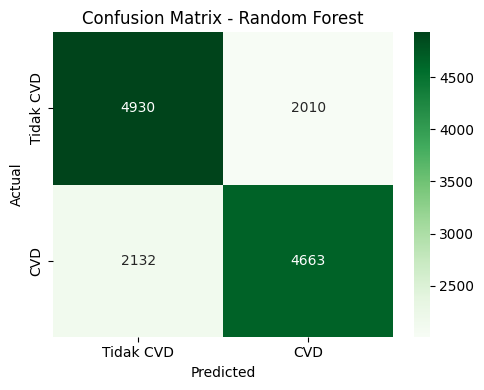

In [ ]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tidak CVD', 'CVD'],
            yticklabels=['Tidak CVD', 'CVD'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# Cek overfitting Random Forest
y_train_pred_rf = rf.predict(X_train_scaled)

print('=== Overfitting Check - Random Forest ===')
print('Train Accuracy :', round(accuracy_score(y_train, y_train_pred_rf), 4))
print('Test Accuracy  :', round(accuracy_score(y_test, y_pred_rf), 4))

=== Overfitting Check - Random Forest ===
Train Accuracy : 0.9763
Test Accuracy  : 0.6984


## Tabel Perbandingan Model

In [ ]:
# Tabel perbandingan performa kedua model
results = {
    'Model': ['Logistic Regression (Baseline)', 'Random Forest (Pembanding)'],
    'Accuracy' : [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall'   : [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1-Score' : [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)]
}

df_results = pd.DataFrame(results)
df_results.set_index('Model', inplace=True)
df_results = df_results.applymap(lambda x: f'{x:.4f}')

print('=== Tabel Perbandingan Performa Model ===')
df_results

=== Tabel Perbandingan Performa Model ===


/tmp/ipykernel_1749/3894991420.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_results = df_results.applymap(lambda x: f'{x:.4f}')


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression (Baseline),0.7228,0.7516,0.6567,0.7009
Random Forest (Pembanding),0.6984,0.6988,0.6862,0.6925


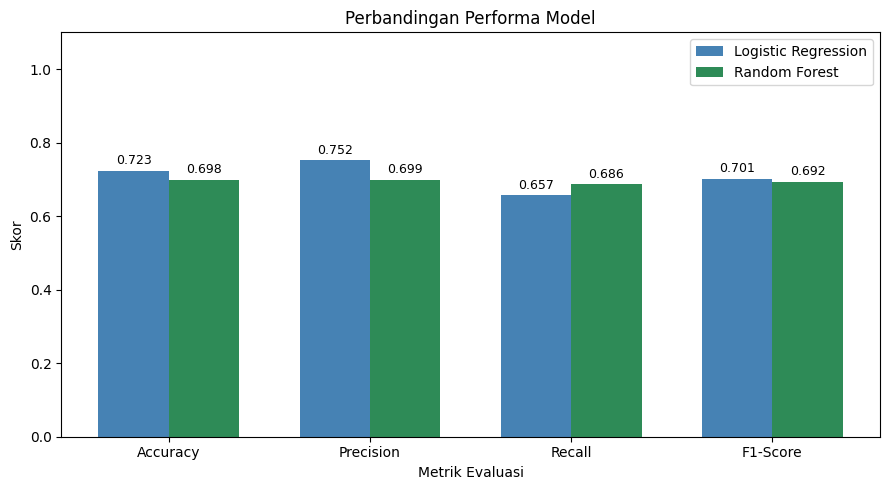

In [ ]:
# Visualisasi perbandingan metrik antar model
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]
rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='seagreen')

ax.set_xlabel('Metrik Evaluasi')
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Performa Model')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

# Tambahkan label nilai di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Hasil eksperimen menunjukkan bahwa Logistic Regression sebagai model baseline
justru menghasilkan performa yang lebih baik dibandingkan Random Forest pada
dataset ini (Accuracy: 72,28% vs 69,84%).

Logistic Regression menunjukkan stabilitas yang baik dengan selisih Train-Test
Accuracy hanya 0,57%, mengindikasikan tidak ada overfitting. Sebaliknya,
Random Forest mengalami overfitting yang serius — Train Accuracy mencapai 97,63%
namun Test Accuracy hanya 69,84% (selisih 27,79%). Hal ini terjadi karena
Random Forest dengan parameter default cenderung membangun pohon yang terlalu
dalam sehingga "menghapal" data training.

Dalam konteks medis prediksi CVD, Recall juga menjadi metrik penting karena
false negative (pasien sakit tapi diprediksi sehat) lebih berbahaya daripada
false positive. Logistic Regression menghasilkan Recall 0.6567, sementara
Random Forest 0.6862 — RF sedikit lebih baik dalam mendeteksi pasien CVD
meskipun secara keseluruhan performa LR lebih konsisten.